# Assignment 2: FOMC Communication and Asset Prices

**Victor Chen (yc8027)**  
FRE-GY 7871 A - NLP and the Investment Process - Fall 2026  
Information set: **September 13, 2026**

This notebook studies FOMC statements, minutes, and Chair communications from Jerome Powell's first day as Chair through the latest pre-meeting information. It uses a monetary-policy phrase list and a FinBERT anchor-similarity score, then relates tone to daily market moves while controlling for the 3-month Treasury yield.

## Reproduction and research design

From `assignment2/`, create an environment and install `requirements.txt`, then run:

```bash
python scripts/run_all.py --refresh --rescore
python scripts/build_notebook.py
```

Raw/intermediate data are downloaded from public sources into ignored `data/` directories and are not committed. The saved outputs below make the notebook viewable without rerunning the downloads. Release times are matched to the Federal Reserve event calendar; pre-close releases use prior-close to same-close changes, while after-close/non-trading-day releases roll to the next close.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name != 'assignment2':
    ROOT = ROOT / 'assignment2'
sys.path.insert(0, str(ROOT))

from src.analysis import document_counts

scores = pd.read_csv(ROOT/'data/interim/document_scores.csv')
events = pd.read_csv(ROOT/'data/interim/event_reactions.csv')
regressions = pd.read_csv(ROOT/'outputs/table3_regressions.csv')
forecast = json.loads((ROOT/'outputs/forecast.json').read_text(encoding='utf-8'))
print(f"Documents: {len(scores)} | Market-linked events: {len(events)}")
print(f"Sample: {scores.release_date.min()} to {scores.release_date.max()}")

Documents: 315 | Market-linked events: 315
Sample: 2018-02-13 to 2026-08-28


## Methods

The phrase-list score is the number of hawkish minus dovish monetary-policy phrase matches per 1,000 words. It includes contextual phrases (for example, “inflation remains elevated” and “inflation has eased”) rather than treating isolated words such as *higher* as hawkish. The language-model score embeds stratified document chunks with `ProsusAI/finbert` and subtracts average cosine similarity to six dovish anchors from similarity to six hawkish anchors. Both measures are standardized within document type using the Powell period, so zero is the Powell-type mean and positive values are more hawkish.

This adapts the factor-similarity, phrase-list, and FinBERT ideas in *Parsing the Fed*. It also follows Doh, Kim, and Yang (2021) in separating qualitative language from the rate action, but the daily window is coarser than their intraday design.

## Table 1. Documents collected, by type and Chair

In [2]:
table1 = pd.read_csv(ROOT/'outputs/table1_document_counts.csv', index_col=0)
display(table1)

,Powell,Warsh,Total
Type,,,
FOMC statements,72,2,74
FOMC minutes,67,2,69
Chair speeches,78,1,79
Chair testimony,26,1,27
Press-conference transcripts,64,2,66
Total,307,8,315


The sample contains 307 Powell-era and eight Warsh-era documents. Press conferences are a subtype of Chair communication, so the five displayed rows sum to the three assignment categories without double-counting.

## Figure 1. Hawkish/dovish tone over time by document type

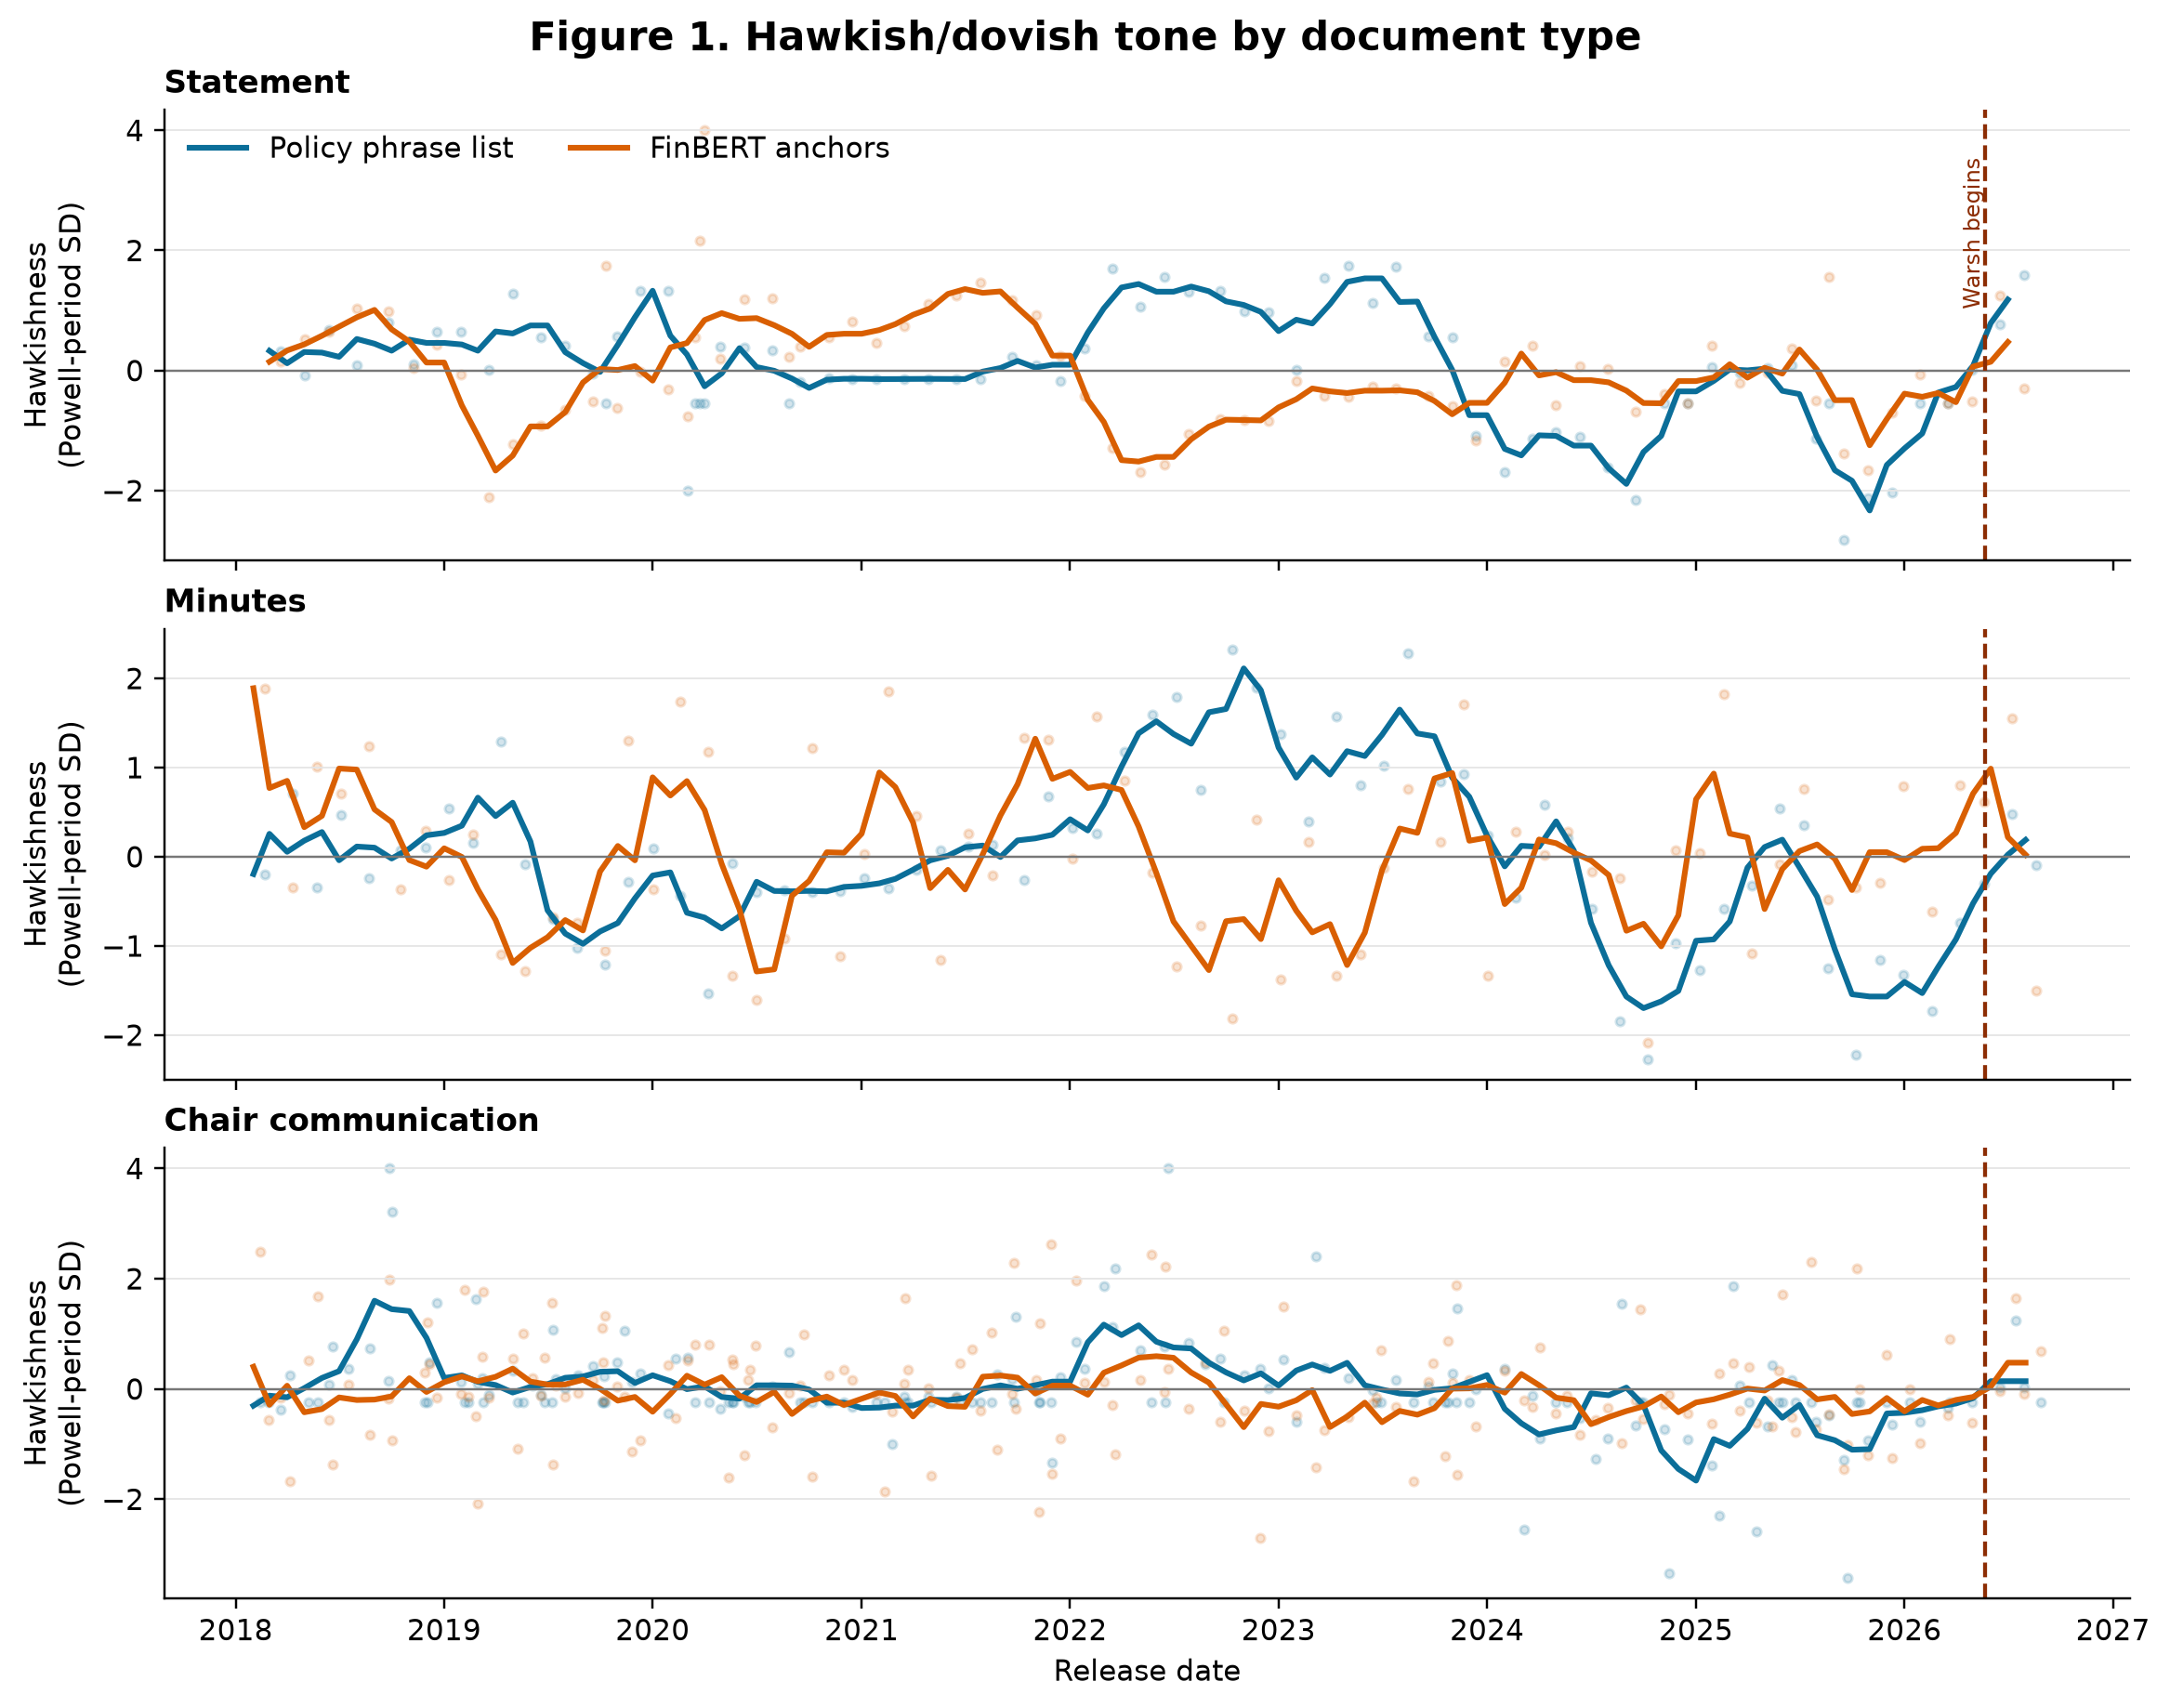

In [3]:
display(Image(filename=str(ROOT/'outputs/figure1_tone_trends.png'), width=1000))

In [4]:
warsh_means = scores.groupby(['chair','doc_type'])[['wordlist_z','finbert_z']].mean().round(2)
display(warsh_means)

wordlist_z  finbert_z
chair  doc_type                                  
Powell Chair communication       -0.01       0.00
       Minutes                   -0.00      -0.00
       Statement                  0.00      -0.00
Warsh  Chair communication        0.26       0.55
       Minutes                    0.19       0.02
       Statement                  1.18       0.47

Warsh-era statements are more hawkish than the Powell statement baseline by **1.18 SD** using the phrase list and **0.47 SD** using FinBERT anchors. Chair communications are 0.26 and 0.55 SD more hawkish, respectively. Minutes are close to the Powell baseline on average. The methods disagree on the July statement and August minutes, an important indication of model uncertainty rather than a reason to select one score ex post.

## Table 2. Warsh-era releases and one-day market reactions

In [5]:
cols = ['release_date','subtype','wordlist_z','finbert_z','dxy_change_pct','spread_change_bp','dgs1_change_bp','growth_value_pp']
table2 = pd.read_csv(ROOT/'outputs/table2_warsh_releases.csv')[cols].copy()
table2.columns = ['Date','Release','Word-list z','FinBERT z','DXY %','10s2s bp','1Y bp','G-V pp']
display(table2.round(2))

,Date,Release,Word-list z,FinBERT z,DXY %,10s2s bp,1Y bp,G-V pp
0,2026-06-17,statement,0.77,1.25,0.55,-9.0,14.0,-0.26
1,2026-06-17,press_conference,0.03,-0.04,0.55,-9.0,14.0,-0.26
2,2026-07-08,minutes,0.48,1.55,-0.09,-1.0,0.0,1.51
3,2026-07-14,testimony,1.24,1.65,-0.34,4.0,-10.0,1.43
4,2026-07-29,statement,1.59,-0.30,-0.57,10.0,-5.0,-0.97
5,2026-07-29,press_conference,0.03,-0.09,-0.57,10.0,-5.0,-0.97
6,2026-08-19,minutes,-0.10,-1.50,-0.82,-6.0,1.0,-0.84
7,2026-08-28,speech,-0.24,0.69,0.54,-8.0,11.0,-0.21


Market reactions are not uniform. The June statement/press conference coincided with a 14 bp rise in the one-year yield and a 9 bp flattening, whereas the July statement/press conference coincided with a 5 bp one-year yield decline and a 10 bp steepening. Same-day statement and press-conference rows share the daily window; this is transparent but limits causal separation at daily frequency.

## Table 3. Market-change regressions with the 3-month bill control

In [6]:
view = regressions.copy()
view['Tone (HC3 SE)'] = view.apply(lambda r: f"{r['Tone coefficient']:.3f} ({r['Tone SE']:.3f})", axis=1)
view['DGS3MO (HC3 SE)'] = view.apply(lambda r: f"{r['DGS3MO coefficient']:.3f} ({r['DGS3MO SE']:.3f})", axis=1)
display(view[['Indicator','Tone method','Tone (HC3 SE)','DGS3MO (HC3 SE)','Adjusted R2','N']].round({'Adjusted R2':3}))

,Indicator,Tone method,Tone (HC3 SE),DGS3MO (HC3 SE),Adjusted R2,N
0,DXY (%),Word list,-0.018 (0.025),0.039 (0.009),0.084,315
1,DXY (%),FinBERT anchors,0.019 (0.024),0.039 (0.009),0.085,315
2,10s2s (bp),Word list,-0.091 (0.256),-0.445 (0.085),0.091,315
3,10s2s (bp),FinBERT anchors,-0.123 (0.229),-0.444 (0.084),0.091,315
4,1-year yield (bp),Word list,-0.024 (0.268),0.963 (0.110),0.322,315
5,1-year yield (bp),FinBERT anchors,-0.127 (0.240),0.965 (0.109),0.322,315
6,Growth - value (pp),Word list,0.073 (0.059),0.002 (0.021),-0.003,315
7,Growth - value (pp),FinBERT anchors,-0.099 (0.068),0.004 (0.021),0.000,315


Each row is a separate OLS regression with HC3 standard errors and document-type fixed effects. No tone coefficient is significant at 10%. The DGS3MO control is the dominant term for DXY and the Treasury indicators; adjusted R-squared ranges from approximately 0% for growth minus value to 32% for the one-year yield. This is weaker tone evidence than the readings, consistent with our much wider daily window, mixed document types, and the absence of a direct surprise/novelty measure.

## Forecast for the September 15-16, 2026 FOMC meeting

In [7]:
rate = pd.Series(forecast['rate_probabilities'], name='Probability (%)')
market_fc = pd.DataFrame(forecast['market_reaction']).T
display(rate.to_frame())
print(f"Probability statement is more hawkish than July: {forecast['more_hawkish_probability']}%")
display(market_fc)

,Probability (%)
Cut,11
Hold,72
Hike,17


Probability statement is more hawkish than July: 41%


,probability_rise,expected_change,unit
DXY (%),45,-0.049503,%
10s2s (bp),35,-1.575376,bp
1-year yield (bp),61,1.231763,bp
Growth - value (pp),55,0.150751,pp


The regularized multinomial model uses 68 prior meetings, the previous statement tone, interim communications, and 20-trading-day changes in the one-year yield and 10s2s spread; its probabilities are blended 80/20 with Laplace-smoothed sample frequencies. The statement-tone model uses the same predictors. Market sizes and sign probabilities average predictions from the two tone regressions and include residual uncertainty.

**Recommendation.** Put on a small DV01-neutral 2s10s flattener (receive fixed in 10-year swaps and pay fixed in 2-year swaps). The model assigns a 65% probability that the 10s2s spread falls and expects about a 1.6 bp decline, the strongest directional signal among the four indicators. The position is deliberately small because the tone coefficients are imprecise. A meeting-day steepening of more than 5 bp, especially alongside a cut and a materially more dovish statement, would reject the thesis.

This is an academic forecast, not investment advice.

## Comparison with the readings

- **Doh, Kim, and Yang (2021):** Their qualitative statement measure can move bond prices even without a rate action. Our DGS3MO-controlled daily results preserve that identification goal but find no statistically reliable tone coefficient, suggesting daily noise and mixed document types dilute the signal.
- **Doh, Song, and Yang (2020/2025):** They place official statements between staff-written hawkish and dovish alternatives and emphasize tone, novelty, expectations, and short windows. Our public-anchor method avoids the alternatives' five-year publication delay, but it cannot identify surprises as cleanly.
- **Parsing the Fed (2021):** We reproduce its phrase-list and FinBERT/factor-similarity families. Like the presentation, the approaches disagree in places and have indicator-specific explanatory power. Our phrase list is explicitly monetary-policy contextual, while the balanced FinBERT anchors avoid equating generic positive financial sentiment with hawkishness.

Sources: [Federal Reserve FOMC calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm), [Federal Reserve speeches](https://www.federalreserve.gov/newsevents/speech/2026-speeches.htm), [Doh, Kim, and Yang](https://www.kansascityfed.org/research/economic-review/how-you-say-it-matters-text-analysis-of-fomc-statements-using-natural-language-processing/), and [Doh, Song, and Yang](https://www.kansascityfed.org/research/research-working-papers/deciphering-federal-reserve-communication-via-text-analysis/).

## Numerical checks

In [8]:
import subprocess
r = subprocess.run([sys.executable, '-m', 'pytest', 'tests', '-q'], cwd=ROOT, capture_output=True, text=True)
print(r.stdout)
assert r.returncode == 0, r.stderr
assert sum(forecast['rate_probabilities'].values()) == 100
assert len(scores[scores.chair.eq('Warsh')]) == 8
print('Forecast probabilities and Warsh sample checks passed.')

....                                                                     [100%]
4 passed in 1.11s

Forecast probabilities and Warsh sample checks passed.
